# Линейная регрессия

В этом ноутбуке начнем с построения самой простейшей модели - линейной регресссии и ее улучшенных моделей, основанных на той же логике.

Содержание:
1. Подготовка данных;
2. Бэйзлайн;
3. Линейная регрессия;
4. Ridge;
5. Lasso;
6. ElasticNet;
7. Сравнение моделей
8. Артефакты
9. Заключение

## 1. Подготовка данных

### 1.1. Импорты

In [95]:
from sklearn.preprocessing import StandardScaler

import pandas as pd
import os

random_state = 42

### 1.2. Загрузка данных

In [96]:
data_path = os.path.join('..', 'data', 'ml-latest-small')

# Загружаем подготовленные датасеты
train = pd.read_csv(os.path.join(data_path, 'train.csv'))
val = pd.read_csv(os.path.join(data_path, 'val.csv'))
test = pd.read_csv(os.path.join(data_path, 'test.csv'))

print(f'train {train.shape}')
print(f'val {val.shape}')
print(f'test {test.shape}')

train (70584, 46)
val (10084, 46)
test (20168, 46)


### 1.3. Отделяем target и применяем scaller

In [97]:
features = [col for col in train.columns if col != 'rating']

scaler = StandardScaler()

# Обучаем скейлер на train, преобразуем все выборки
X_train = scaler.fit_transform(train[features])
X_val = scaler.transform(val[features])
X_test = scaler.transform(test[features])

print("X_train min:", X_train.min(), "max:", X_train.max())
print("X_train mean:", X_train.mean(), "std:", X_train.std())

y_train = train['rating'].values
y_val = val['rating'].values
y_test = test['rating'].values

X_train min: -7.142605985427561 max: 10.13903348450926
X_train mean: 2.0043771054222226e-17 std: 0.9775252199076787


## 2. Бэйзлайн

Эта модель ставит каждому фильму среднюю оценку во всем датасете. Она необходима для сравнения более сложных моделей.

### 2.1. Импорты

In [98]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

### 2.2. Предсказание

In [99]:
y_train_pred = np.full_like(y_train, y_train.mean())
y_test_pred = np.full_like(y_test, y_train.mean())

### 2.3. Оценка


In [100]:
def evaluate(y_true: pd.Series, y_pred: pd.Series, name: str) -> tuple[float, float]:
    """
    Функция оценки. Считает и выводит rmse и mae.
    Параметры:
      y_true - серия с реальными оценками
      y_pred - серия с предсказанными оценками
      name - название датасета
    Возвращает:
      rmse - средне квадратическое отклонение
      mae - среднее абсолютное отклонение
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name}: RMSE = {rmse:.4f}, MAE = {mae:.4f}")

    return rmse, mae

models_results = []

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

models_results.append({
    'name': 'baseline',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'alpha': '-',
    'l1_ratio': '-',
    'max_iter': '-',
    'random_state': '-'
})

Train: RMSE = 1.0321, MAE = 0.8231
Test: RMSE = 1.0786, MAE = 0.8538


## 3. Линейная регрессия

### 3.1. Импорты

In [101]:
from sklearn.linear_model import LinearRegression

### 3.2. Обучение и предсказания

In [102]:
lr = LinearRegression() #  создаем модель
lr.fit(X_train, y_train) #  обучаем

# Предсказания
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)

### 3.3. Оценка

In [103]:
train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

models_results.append({
    'name': 'LinearRegression',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'alpha': '-',
    'l1_ratio': '-',
    'max_iter': '-',
    'random_state': '-'
})

Train: RMSE = 0.8459, MAE = 0.6529
Test: RMSE = 1.0271, MAE = 0.8125


## 4. Ridge

В отличии от обычной линейной регрессии Ridge препятствует переобучению и вводит штрафы за слишком большие веса

### 4.1. Импорты

In [104]:
from sklearn.linear_model import Ridge

### 4.2. Сырой Ridge

In [105]:
ridge_row = Ridge()
ridge_row.fit(X_train, y_train)

y_train_pred = ridge_row.predict(X_train)
y_test_pred = ridge_row.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

models_results.append({
    'name': 'RidgeRow',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'alpha': '-',
    'l1_ratio': '-',
    'max_iter': '-',
    'random_state': '-'
})

Train: RMSE = 0.8459, MAE = 0.6529
Test: RMSE = 1.0271, MAE = 0.8124


### 4.3. Ridge с подбором параметров

#### 4.3.1. Подбираем гиперпараметры

In [106]:
param_grid = {'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0, 100.0]}

best_model = None
best_alpha = None
best_rmse = float('inf')

for alpha in param_grid['alpha']:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_val_pred = ridge.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f"alpha={alpha:<6} Val RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha
        best_model = ridge

print(f"Лучший alpha: {best_alpha} | Val RMSE={best_rmse:.4f}")

alpha=0.01   Val RMSE=0.9754
alpha=0.05   Val RMSE=0.9754
alpha=0.1    Val RMSE=0.9754
alpha=0.5    Val RMSE=0.9754
alpha=1.0    Val RMSE=0.9754
alpha=2.0    Val RMSE=0.9754
alpha=5.0    Val RMSE=0.9754
alpha=10.0   Val RMSE=0.9754
alpha=20.0   Val RMSE=0.9754
alpha=50.0   Val RMSE=0.9754
alpha=100.0  Val RMSE=0.9754
Лучший alpha: 100.0 | Val RMSE=0.9754


#### 4.3.2 Оцениваем лучшую модель

In [107]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

models_results.append({
    'name': 'RidgeGrid',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'alpha': best_alpha,
    'l1_ratio': '-',
    'max_iter': '-',
    'random_state': '-'
})

Train: RMSE = 0.8459, MAE = 0.6529
Test: RMSE = 1.0271, MAE = 0.8124


## 5. Lasso

В процессе обучения обнуляет несущественные признаки

### 5.1. Импорты

In [108]:
from sklearn.linear_model import Lasso

### 5.2. Сырой Lasso

In [109]:
lasso_row = Lasso(random_state=random_state)
lasso_row.fit(X_train, y_train)

y_train_pred = lasso_row.predict(X_train)
y_test_pred = lasso_row.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

models_results.append({
    'name': 'LassoRow',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'alpha': '-',
    'l1_ratio': '-',
    'max_iter': '-',
    'random_state': random_state
})

Train: RMSE = 1.0321, MAE = 0.8231
Test: RMSE = 1.0786, MAE = 0.8538


### 5.3. Lasso с подбором гиперпараметров

#### 5.3.1. Подбираем гиперпараметры

In [110]:
param_grid = {'alpha':  [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]}

best_model = None
best_alpha = None
best_rmse = float('inf')

for alpha in param_grid['alpha']:
    lasso = Lasso(alpha=alpha, max_iter=5000, random_state=random_state)
    lasso.fit(X_train, y_train)
    y_val_pred = lasso.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    print(f"alpha={alpha:<6} Val RMSE={rmse:.4f}")

    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha
        best_model = lasso

print(f"Лучший alpha: {best_alpha} | Val RMSE={best_rmse:.4f})")

alpha=0.0001 Val RMSE=0.9754
alpha=0.0005 Val RMSE=0.9753
alpha=0.001  Val RMSE=0.9752
alpha=0.005  Val RMSE=0.9753
alpha=0.01   Val RMSE=0.9758
alpha=0.05   Val RMSE=0.9772
alpha=0.1    Val RMSE=0.9776
alpha=0.5    Val RMSE=1.0418
alpha=1.0    Val RMSE=1.0418
Лучший alpha: 0.001 | Val RMSE=0.9752)


#### 5.3.2. Оцениваем лучшую модель

In [111]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

models_results.append({
    'name': 'LassoGrid',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'alpha': best_alpha,
    'l1_ratio': '-',
    'max_iter': 5000,
    'random_state': random_state
})

Train: RMSE = 0.8460, MAE = 0.6530
Test: RMSE = 1.0270, MAE = 0.8122


## 6. ElasticNet

Комбинирует подходы предыдущих двух моделей

### 6.1. Импорты

In [112]:
from sklearn.linear_model import ElasticNet

### 6.2. Сырой ElasticNet

In [113]:
elastic_net_row = ElasticNet(random_state=random_state)
elastic_net_row.fit(X_train, y_train)

y_train_pred = elastic_net_row.predict(X_train)
y_test_pred = elastic_net_row.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

models_results.append({
    'name': 'ElasticNetRow',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'alpha': best_alpha,
    'l1_ratio': '-',
    'max_iter': '-',
    'random_state': random_state
})

Train: RMSE = 1.0321, MAE = 0.8231
Test: RMSE = 1.0786, MAE = 0.8538


### 6.3. ElasticNet с подбором гиперпараметров

#### 6.3.1. Подбираем гиперпараметры

In [114]:
param_grid = {
    'alpha': [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0], #  сила регуляризаций
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9] #  доля влияния l1 регуляризации, l2 = 1 - l1_ratio
}

best_rmse = float('inf')
best_params = None
best_model = None

for alpha in param_grid['alpha']:
    for l1_ratio in param_grid['l1_ratio']:

        elastic = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000, random_state=random_state)
        elastic.fit(X_train, y_train)

        y_val_pred = elastic.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        n_nonzero = np.sum(elastic.coef_ != 0)
        print(f"alpha={alpha:<6} l1_ratio={l1_ratio:<4} | Val RMSE={rmse:.4f} | features={n_nonzero}")

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = {'alpha': alpha, 'l1_ratio': l1_ratio}
            best_model = elastic

print(f"Лучший alpha={best_params['alpha']:<6} l1_ratio={best_params['l1_ratio']:<4} | Val RMSE={best_rmse:.4f}")

alpha=0.001  l1_ratio=0.1  | Val RMSE=0.9754 | features=42
alpha=0.001  l1_ratio=0.3  | Val RMSE=0.9753 | features=42
alpha=0.001  l1_ratio=0.5  | Val RMSE=0.9753 | features=42
alpha=0.001  l1_ratio=0.7  | Val RMSE=0.9753 | features=42
alpha=0.001  l1_ratio=0.9  | Val RMSE=0.9752 | features=41
alpha=0.005  l1_ratio=0.1  | Val RMSE=0.9752 | features=42
alpha=0.005  l1_ratio=0.3  | Val RMSE=0.9750 | features=38
alpha=0.005  l1_ratio=0.5  | Val RMSE=0.9750 | features=32
alpha=0.005  l1_ratio=0.7  | Val RMSE=0.9752 | features=27
alpha=0.005  l1_ratio=0.9  | Val RMSE=0.9753 | features=22
alpha=0.01   l1_ratio=0.1  | Val RMSE=0.9749 | features=41
alpha=0.01   l1_ratio=0.3  | Val RMSE=0.9750 | features=31
alpha=0.01   l1_ratio=0.5  | Val RMSE=0.9752 | features=20
alpha=0.01   l1_ratio=0.7  | Val RMSE=0.9755 | features=19
alpha=0.01   l1_ratio=0.9  | Val RMSE=0.9757 | features=17
alpha=0.05   l1_ratio=0.1  | Val RMSE=0.9745 | features=24
alpha=0.05   l1_ratio=0.3  | Val RMSE=0.9760 | features=

#### 6.3.2. Обучаем лучшую модель и оцениваем

In [115]:
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_rmse, train_mae = evaluate(y_train, y_train_pred, "Train")
test_rmse, test_mae = evaluate(y_test, y_test_pred, "Test")

models_results.append({
    'name': 'ElasticNetGrid',
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'alpha': best_params['alpha'],
    'l1_ratio': best_params['l1_ratio'],
    'max_iter': 10000,
    'random_state': random_state
})

Train: RMSE = 0.8467, MAE = 0.6539
Test: RMSE = 1.0264, MAE = 0.8105


In [116]:
feature_importance = pd.DataFrame({
    'feature': features,
    'coef': best_model.coef_
}).sort_values('coef', key=abs, ascending=False).reset_index(drop=True)

feature_importance

,feature,coef
0,movie_avg_rating,0.412871
1,user_avg_rating,0.075643
2,user_avg_Drama,0.073205
3,user_avg_Comedy,0.054410
4,user_avg_Action,0.039593
5,timestamp,-0.025737
6,user_avg_Thriller,0.023485
7,user_avg_Sci-Fi,0.023482
8,user_avg_Romance,0.018585
9,user_avg_Animation,0.017624


## 7. Сравнение моделей и анализ лучшей

### 7.1. Импорты

In [117]:
import matplotlib.pyplot as plt

### 7.2. Сравнение моделей

In [118]:
results_df = pd.DataFrame(models_results)
results_df

,name,train_rmse,train_mae,test_rmse,test_mae,alpha,l1_ratio,max_iter,random_state
0,baseline,1.032099,0.823060,1.078622,0.853800,-,-,-,-
1,LinearRegression,0.845930,0.652920,1.027131,0.812450,-,-,-,-
2,RidgeRow,0.845930,0.652920,1.027131,0.812449,-,-,-,-
3,RidgeGrid,0.845931,0.652935,1.027093,0.812386,100.0,-,-,-
4,LassoRow,1.032099,0.823060,1.078622,0.853800,-,-,-,42
5,LassoGrid,0.845980,0.652987,1.026990,0.812187,0.001,-,5000,42
6,ElasticNetRow,1.032099,0.823060,1.078622,0.853800,0.001,-,-,42
7,ElasticNetGrid,0.846675,0.653851,1.026355,0.810536,0.05,0.1,10000,42


### 7.3. Анализ лучшей модели

In [119]:
best_row = results_df.loc[results_df['test_rmse'].idxmin()]

best_params = {
    'model': best_row['name'],
    'alpha': best_row['alpha'] if best_row['alpha'] != '-' else None,
    'l1_ratio': best_row['l1_ratio'] if best_row['l1_ratio'] != '-' else None,
    'max_iter': best_row['max_iter'] if best_row['max_iter'] != '-' else None,
    'random_state': best_row['random_state'] if best_row['random_state'] != '-' else None,
    'train_rmse': best_row['train_rmse'],
    'train_mae': best_row['train_mae'],
    'test_rmse': best_row['test_rmse'],
    'test_mae': best_row['test_mae']
}

for name, value in best_params.items():
  print(f'{name}: {value}')

model: ElasticNetGrid
alpha: 0.05
l1_ratio: 0.1
max_iter: 10000
random_state: 42
train_rmse: 0.8466750856190152
train_mae: 0.6538514686710754
test_rmse: 1.0263547983612185
test_mae: 0.8105363484015479


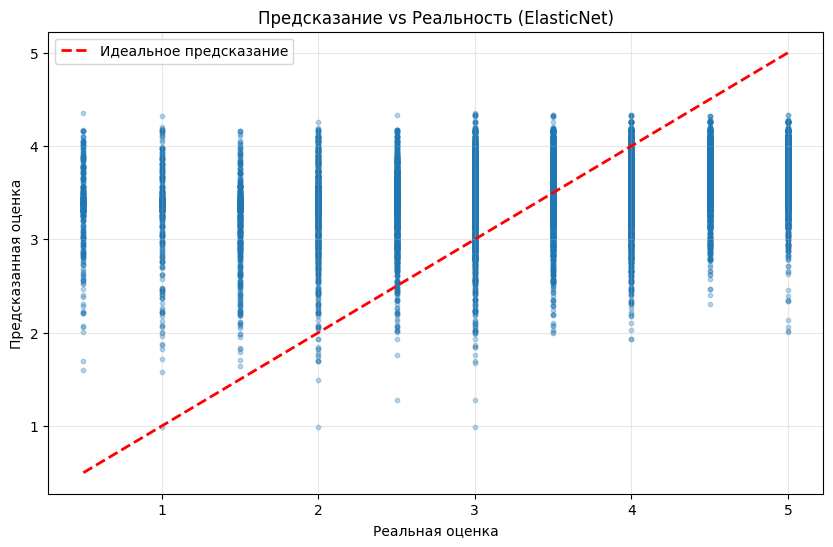

In [120]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(y_test, y_test_pred, alpha=0.3, s=10)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальное предсказание')
ax.set_xlabel('Реальная оценка')
ax.set_ylabel('Предсказанная оценка')
ax.set_title(f'Предсказание vs Реальность (ElasticNet)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 8. Артефакты

In [123]:
import json

artifacts_path = os.path.join('..', 'artifacts', 'exp02')
os.makedirs(artifacts_path, exist_ok=True)

results_df.to_csv(os.path.join(artifacts_path, 'runs.csv'), index=False)

feature_importance.to_csv(os.path.join(artifacts_path, 'feature_importance.csv'), index=False)

with open(os.path.join(artifacts_path, 'best_model_params.json'), 'w') as f:
    json.dump(best_params, f, indent=4)

fig.savefig(os.path.join(artifacts_path, 'prediction_vs_actual.png'), dpi=150, bbox_inches='tight')

## 9. Заключение

По итогу эксперимента линейная регрессия не смогла показать сильного результата, отличного от бэйзлайна. Это означает, что модель не может поймать зависимости между признаками.

Использование различных модификаций линейной регрессии также не дало результатов: результат лучшей модели отличается от обычной на уровне погрешности.

Из этого можно сделать вывод: линейная регрессия малопригодна для поставленной задачи